# Getting started with MOOGP

MOOGP fits a Multi-Output Orthogonal Gaussian Process to data with one or more outputs that share structure. This notebook walks through the basic workflow on a 1D, 3-output toy problem (the Forrester functions):

1. Generate noisy training data.
2. Construct a `MOOGP` model.
3. Fit it (maximum likelihood).
4. Predict mean and uncertainty on a dense grid.
5. Plot the fit.

The data is just $f_1, f_2, f_3$ evaluated on a Latin-hypercube design in $[0, 1]$ with independent Gaussian noise per output.

In [1]:
# Make the repo root importable whether the notebook is launched from
# the repo root or from examples/. Once moogp is installed (pip install -e .)
# this cell becomes a no-op.
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from moogp.datasets import generate_forrester_data
from moogp.model import MOOGP

for _candidate in (Path.cwd(), Path.cwd().parent):
    if (_candidate / "moogp" / "__init__.py").exists():
        sys.path.insert(0, str(_candidate.resolve()))
        break

## 1. Generate data

`generate_forrester_data` returns a `dict` with `X` (raw inputs in `[0, 1]`), `X_scaled` (mapped to `[-1, 1]`), `y` (noisy observations), and `f` (the noise-free truth). MOOGP expects the working-scale `X_scaled` key when `standardize_x=False`; with the default `standardize_x="unitcube"`, raw `X` works too.

In [28]:
n_train = 25
p = 3  # number of outputs
sigma_eps2_true = np.array([1.0, 0.5, 0.1])  # per-output noise variance

data = generate_forrester_data(
    n=n_train,
    seed=0,
    with_error=True,
    error_per_output=sigma_eps2_true,
)
X_train = data["X"]              # shape (n, 1) on [0, 1]
Y_train = data["y"]              # shape (n, p) noisy
F_train = data["f"]              # shape (n, p) noise-free
print("X_train:", X_train.shape, "  Y_train:", Y_train.shape)

X_train: (25, 1)   Y_train: (25, 3)


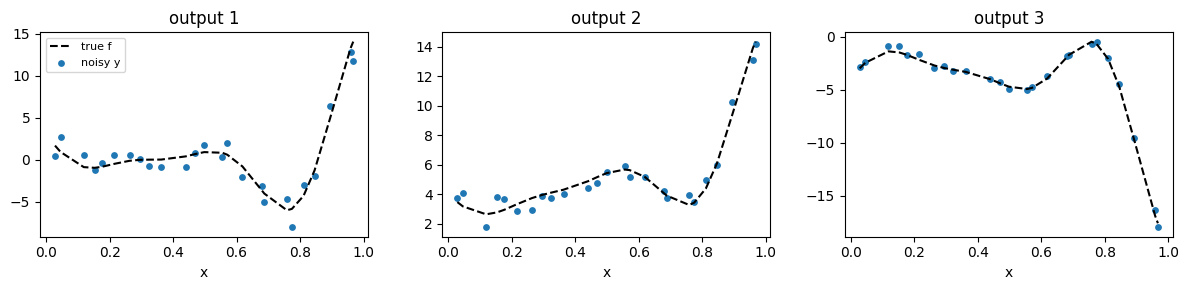

In [29]:
fig, axes = plt.subplots(1, p, figsize=(12, 3), sharex=True)
for j, ax in enumerate(axes):
    order = np.argsort(X_train[:, 0])
    ax.plot(X_train[order, 0], F_train[order, j], "k--", label="true f")
    ax.scatter(X_train[:, 0], Y_train[:, j], s=15, label="noisy y")
    ax.set_title(f"output {j + 1}")
    ax.set_xlabel("x")
axes[0].legend(loc="best", fontsize=8)
fig.tight_layout()

## 2. Construct the model

Key constructor arguments:

  * **`terms`** — the basis for the trend $g(x)$. `[None, 1]` means intercept + main effect of $x_1$ (one-based indexing). For higher-dimensional inputs you can include interactions, e.g. `[None, 1, 2, (1, 2)]`.
  * **`q`** — number of latent orthogonal GPs (`q <= p`). With `q = p` the model can express any per-output covariance; smaller `q` enforces low-rank coupling between outputs.
  * **`orthogonal=True`** — use the orthogonalized SE kernel so the GP component is orthogonal to the trend basis (recommended; this is the central idea of MOOGP).
  * **`learn_sigma_eps=True`** — learn the per-output noise variance from the data.

Other useful defaults: `standardize_y="zscore"`, `standardize_x="unitcube"`, `use_analytical_grad=True`.

In [30]:
d = X_train.shape[1]
q = p  # full-rank coupling

model = MOOGP(
    terms=[None, 1],          # intercept + linear trend in x
    q=q,
    orthogonal=True,
    learn_sigma_eps=True,
)

## 3. Fit

`fit` packs the hyperparameters into a single vector `theta` and minimizes the negative log-likelihood with L-BFGS-B. You must supply an initial `theta0` and per-coordinate `bounds`.

The packing is: for each of the `q` latent GPs, one `log(sigma2)` followed by `d` `log(ell)` values; then, when `learn_sigma_eps=True`, the per-output `log(sigma_eps2)` values.

In [31]:
theta0 = []
bounds = []
for _ in range(q):
    theta0.append(np.log(1.0))                                  # log(sigma2_j)
    theta0.extend([np.log(0.5)] * d)                            # log(ell_j)
    bounds.append((np.log(1e-3), np.log(1e3)))                  # sigma2 bounds
    bounds.extend([(np.log(0.05), np.log(5.0))] * d)            # ell bounds
# Per-output noise (learn_sigma_eps=True):
theta0.extend([np.log(0.5)] * p)
bounds.extend([(np.log(1e-6), np.log(10.0))] * p)
theta0 = np.array(theta0)

model.fit(data=data, theta0=theta0, bounds=bounds)
print("converged:", model.opt_result.success, "  NLL:", model.nll_hat)

converged: True   NLL: -0.3880681465343321


## 4. Predict

`predict` returns the posterior mean (shape `(n_star, p)`) and, with `return_std=True`, the per-output predictive standard deviation. By default `predict_observation=True` includes the learned $\sigma^2_\varepsilon$ in the returned variance; set `predict_observation=False` for the latent function uncertainty only.

In [32]:
X_star = np.linspace(0, 1, 200).reshape(-1, 1)
Y_mean, Y_std = model.predict(X_star, return_std=True)
Y_mean.shape, Y_std.shape

((200, 3), (200, 3))

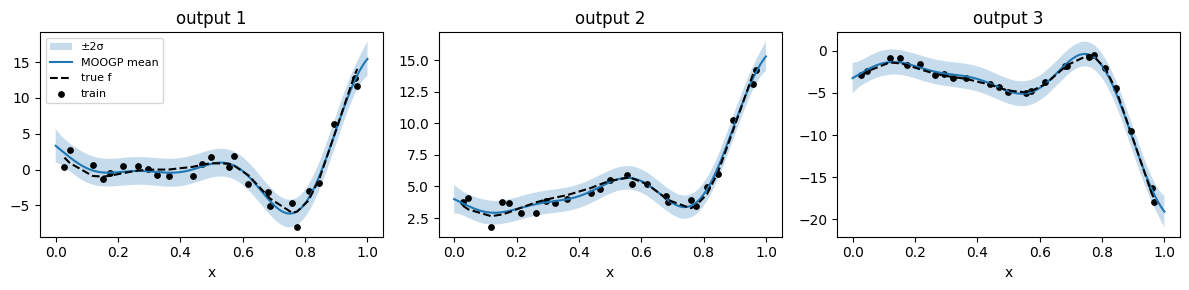

In [33]:
fig, axes = plt.subplots(1, p, figsize=(12, 3), sharex=True)
for j, ax in enumerate(axes):
    x = X_star[:, 0]
    ax.fill_between(x, Y_mean[:, j] - 2 * Y_std[:, j], Y_mean[:, j] + 2 * Y_std[:, j],
                    alpha=0.25, label="\u00b12\u03c3")
    ax.plot(x, Y_mean[:, j], label="MOOGP mean")
    order = np.argsort(X_train[:, 0])
    ax.plot(X_train[order, 0], F_train[order, j], "k--", label="true f")
    ax.scatter(X_train[:, 0], Y_train[:, j], s=15, c="k", label="train")
    ax.set_title(f"output {j + 1}")
    ax.set_xlabel("x")
axes[0].legend(loc="best", fontsize=8)
fig.tight_layout()

## 5. Inspect fitted hyperparameters

After `fit`, `model.cache` holds the unpacked hyperparameters in a usable form. The most useful entries:

  * `lat_params` — list of `(sigma2_j, ell_j)` for each of the `q` latent GPs.
  * `sigma_eps2` — fitted per-output noise variances on the standardized scale (`sigma_eps2_raw` is on the original scale).
  * `Psi` — the fitted $p \times q$ mixing matrix.
  * `bhat` — the fitted trend coefficients (one column per output).

In [35]:
for j, (sigma2_j, ell_j) in enumerate(model.cache["lat_params"]):
    print(f"latent GP {j}: sigma2={sigma2_j:.3f}  ell={np.round(ell_j, 3)}")
print("fitted sigma_eps2 (raw scale):", np.round(model.cache["sigma_eps2_raw"], 3))
print("true sigma_eps2:               ", sigma_eps2_true)

latent GP 0: sigma2=961.623  ell=[0.467]
latent GP 1: sigma2=0.267  ell=[5.]
latent GP 2: sigma2=0.010  ell=[0.625]
fitted sigma_eps2 (raw scale): [0.864 0.195 0.483]
true sigma_eps2:                [1.  0.5 0.1]


## Where to go from here

  * **Multi-dimensional inputs** — `terms` extends naturally; e.g. for $d = 4$ inputs use `[None, 1, 2, 3, 4]` (intercept + four main effects) or add interactions like `(1, 2)`.
  * **Larger `p`** — keep `q < p` to enforce low-rank coupling between outputs and reduce parameter count.
  * **Heterogeneous noise structure** — pass `diag_error_structure=[3, 2, 4]` (sums to `p`) to share one noise variance across each block of outputs.
  * **Borehole example** — see `moogp/main_borehole_example.py` for an 8-dim, multi-location example with a held-out test set.